In [1]:
import glob
import os.path as osp
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import rel_entr
from scipy.stats import gaussian_kde, ks_2samp, chi2
from scipy.integrate import cumulative_trapezoid
from statsmodels.tsa.statespace.structural import UnobservedComponents
from scipy.stats import ttest_1samp

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.dpi"] = 100
#np.set_printoptions(suppress=True, precision=4)


In [2]:
RUN_TYPE = 'sampling'
RESULTS_ROOT = osp.abspath(osp.join("..", "data", "results_mp_sampling"))
MODEL_NAME = "gpt4o_mini" # All or specific model name
_KNOWN_DATASETS = sorted(
    ["arc_c", "arc_e", "csqa", "obqa", "race", "sciq"], key=len, reverse=True
)
SEED = None
DATASET = "obqa"  # All or specific dataset name
OUTPUT_FILE_NAME = 'martingale_sampling_results.npz'

In [3]:
def parse_run_folder(folder_name: str):
    """Split '<dataset>_<model>' into (dataset, model) using known dataset codes."""
    for ds in _KNOWN_DATASETS:
        prefix = ds + "_"
        if folder_name.startswith(prefix):
            return ds, folder_name[len(prefix):]
    return folder_name, "unknown"

all_run_dirs = sorted(glob.glob(osp.join(RESULTS_ROOT, "*")))

registry_rows = []
for run_dir in all_run_dirs:
    folder = osp.basename(run_dir)
    dataset, model = parse_run_folder(folder)
    npz_path = osp.join(run_dir, "martingale_check", RUN_TYPE, OUTPUT_FILE_NAME)
    registry_rows.append({
        "folder": folder,
        "dataset": dataset,
        "model": model,
        "npz_path": npz_path,
        "available": osp.exists(npz_path),
    })

registry = pd.DataFrame(registry_rows)

if MODEL_NAME != "all":
    registry = registry[registry["model"] == MODEL_NAME]

display(registry)


missing = registry.loc[~registry["available"], "folder"].tolist()
if missing:
    print(f"Skipping {len(missing)} incomplete run(s) (no martingale_results.npz found): {missing}")

registry = registry[registry["available"]].reset_index(drop=True)
print(f"\n{len(registry)} completed run(s) available for testing.")


,folder,dataset,model,npz_path,available
1,arc_c_gpt4o_mini,arc_c,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
4,arc_e_gpt4o_mini,arc_e,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
6,csqa_gpt4o_mini,csqa,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
7,obqa_gpt4o_mini,obqa,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True



4 completed run(s) available for testing.


In [4]:
def normalize_distributions(d: np.ndarray) -> np.ndarray:
    """Coerce to (Q, J, K+1, C). (K+1,C)->(1,1,K+1,C); (Q,K+1,C)->(Q,1,K+1,C)."""
    if d.ndim == 2:
        d = d[np.newaxis, np.newaxis, :]
    elif d.ndim == 3:
        d = d[:, np.newaxis, :]
    return d


def load_run(npz_path: str, seed: str = None) -> dict:
    """Load one seed's results dict from a martingale_results.npz file."""
    if seed:
        raw = np.load(npz_path, allow_pickle=True)
        seed = seed or list(raw.keys())[0]
        dat = raw[seed].item()
    else:
        with np.load(npz_path, allow_pickle=True) as raw:
            dat = {key: raw[key] for key in raw.files}
            if "metadata" in dat:
                dat["metadata"] = dat["metadata"].item()

    dat["distributions"] = normalize_distributions(np.asarray(dat["distributions"], dtype=np.float64))
    return dat


# Sanity-check the loader on the first available run
_example = load_run(registry.loc[0, "npz_path"], seed=SEED)
Q, J, Kp1, C = _example["distributions"].shape
print(f"Example run: {registry.loc[0, 'folder']}")
print(f"  distributions shape: (Q={Q} questions, J={J} trajectories, K+1={Kp1} steps, C={C} classes)")
print(f"  keys: {list(_example.keys())}")

Example run: arc_c_gpt4o_mini
  distributions shape: (Q=5 questions, J=5 trajectories, K+1=50 steps, C=5 classes)
  keys: ['logits', 'probs', 'distributions', 'labels', 'label_history', 'branch_logits', 'branch_probs', 'expected_next', 'residuals', 'error_l1', 'error_l2', 'error_max', 'centered_logits', 'entropy', 'js_from_initial', 'true_labels', 'input_texts', 'data_indices', 'selected_dataset_indices', 'trajectory_seeds', 'prompt_history', 'branch_prompt_history', 'metadata']


In [5]:
DATASET_KEY = DATASET + '_' + MODEL_NAME
DATA_PATH = registry.loc[registry["folder"].str.lower().str.contains(DATASET_KEY.lower()), "npz_path"].values[0]
dat = load_run(DATA_PATH, seed=SEED)
print(f'Shape of distributions: {dat["distributions"].shape} \n')
print(f'Shape of residuals: {dat["residuals"].shape} \n')

Shape of distributions: (2, 5, 50, 4) 

Shape of residuals: (2, 5, 49, 4) 



In [6]:
def mean_sd_of_residuals(residuals: np.ndarray, ax) -> tuple[np.ndarray, np.ndarray]:
    """Compute mean and standard deviation of residuals across trajectories."""
    mean_residuals = np.mean(residuals, axis=ax)  # Mean across trajectories
    sd_residuals = np.std(residuals, axis=ax)     # Std dev across trajectories

    print(f"Mean residuals over axis {ax}: {mean_residuals}, \n SD residuals over axis {ax}: {sd_residuals} \n")

In [7]:
# assuming shape (Q, R, T, C)
mean_sd_of_residuals(dat["residuals"], ax=(0,1,2))

# assuming shape (Q, R, T, C)
mean_sd_of_residuals(dat["residuals"], ax=(1,2))

Mean residuals over axis (0, 1, 2): [ 3.82271451e-06 -1.21116922e-03 -3.64593671e-04  1.57194018e-03], 
 SD residuals over axis (0, 1, 2): [0.00021835 0.03154277 0.03443143 0.05266022] 

Mean residuals over axis (1, 2): [[ 2.82051930e-10 -7.11064183e-08  2.89064408e-09  6.79337223e-08]
 [ 7.64514698e-06 -2.42226734e-03 -7.29190233e-04  3.14381242e-03]], 
 SD residuals over axis (1, 2): [[1.05550431e-07 7.70061706e-06 4.71983904e-07 7.26444280e-06]
 [3.08740095e-04 4.45753162e-02 4.86906695e-02 7.44396156e-02]] 



In [8]:
def trajectory_cluster_bootstrap(
    residuals: np.ndarray,
    class_labels=None,
    n_bootstrap: int = 20_000,
    confidence: float = 0.95,
    seed: int = 42,
    epsilon: float = 1e-3,
) -> pd.DataFrame:
    """
    Pointwise bootstrap confidence intervals for the time-averaged mean
    residual of each class.

    Parameters
    ----------
    residuals:
        Array with shape (Q, J, T, C).
    """
    res = np.asarray(residuals, dtype=np.float64)

    if res.ndim != 4:
        raise ValueError("residuals must have shape (Q, J, T, C)")
    if epsilon <= 0:
        raise ValueError("epsilon must be strictly positive.")

    Q, J, T, C = res.shape

    # Average dependent observations within each trajectory.
    # Shape: (Q, J, C)
    trajectory_means = np.nanmean(res, axis=2)

    # Regard every (question, trajectory) pair as one bootstrap cluster.
    # Shape: (Q * J, C)
    clusters = trajectory_means.reshape(Q * J, C)
    n_clusters = len(clusters)

    observed_mean = np.nanmean(clusters, axis=0)

    rng = np.random.default_rng(seed)
    bootstrap_means = np.empty((n_bootstrap, C))

    for b in range(n_bootstrap):
        # Resample complete trajectories with replacement.
        indices = rng.integers(0, n_clusters, size=n_clusters)
        bootstrap_means[b] = np.nanmean(clusters[indices], axis=0)

    alpha = 1.0 - confidence
    ci_low, ci_high = np.quantile(
        bootstrap_means,
        [alpha / 2, 1 - alpha / 2],
        axis=0,
    )

    if class_labels is None:
        class_labels = np.arange(C)

    return pd.DataFrame({
        "class": class_labels,
        "mean_residual": observed_mean,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "zero_in_ci": (ci_low <= 0) & (ci_high >= 0),
        "reject_mean_zero": (ci_low > 0) | (ci_high < 0),
        "epsilon": epsilon,
        # Conservative practical-equivalence rule using the full 95% CI.
        "ci_inside_equivalence_region": (ci_low >= -epsilon) & (ci_high <= epsilon),
    })

In [9]:
EPSILON_CLASS = 1e-3  # 0.1 percentage points per class
EPSILON_L2 = 1e-3     # tolerance for the full residual-vector magnitude
EPSILON_GRID = np.array([1e-4, 1e-3, 1e-2])  # sensitivity analysis

labels = dat.get("metadata", {}).get(
    "label_chars",
    range(dat["residuals"].shape[-1]),
)

bootstrap_results = trajectory_cluster_bootstrap(
    dat["residuals"],
    class_labels=labels,
    n_bootstrap=20_000,
    confidence=0.95,
    seed=42,
    epsilon=EPSILON_CLASS,
)

display(bootstrap_results)

,class,mean_residual,ci_low,ci_high,zero_in_ci,reject_mean_zero,epsilon,ci_inside_equivalence_region
0,A,0.000004,-0.000004,0.000015,True,False,0.001,True
1,B,-0.001211,-0.003449,0.000437,True,False,0.001,False
2,C,-0.000365,-0.001237,0.000474,True,False,0.001,False
3,D,0.001572,-0.000603,0.004402,True,False,0.001,False


In [10]:
def _one_sample_tost(values, epsilon: float, alpha: float = 0.05) -> dict:
    """Two one-sided tests for -epsilon < E[values] < epsilon."""
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if epsilon <= 0:
        raise ValueError("epsilon must be strictly positive.")
    if len(values) < 2:
        raise ValueError("At least two trajectory-level observations are required.")

    mean = values.mean()
    sem = stats.sem(values)
    df = len(values) - 1
    exact_test = stats.ttest_1samp(values, popmean=0.0, alternative="two-sided")
    exact_critical = stats.t.ppf(1 - alpha / 2, df=df)
    equivalence_critical = stats.t.ppf(1 - alpha, df=df)
    p_lower = stats.ttest_1samp(values, popmean=-epsilon, alternative="greater").pvalue
    p_upper = stats.ttest_1samp(values, popmean=epsilon, alternative="less").pvalue
    tost_p = max(p_lower, p_upper)

    return {
        "n_trajectories": len(values),
        "mean_residual": mean,
        "t_statistic": exact_test.statistic,
        "p_value_exact_zero": exact_test.pvalue,
        "ci_95_low": mean - exact_critical * sem,
        "ci_95_high": mean + exact_critical * sem,
        # A 90% CI is equivalent to a TOST at alpha=0.05.
        "equivalence_ci_90_low": mean - equivalence_critical * sem,
        "equivalence_ci_90_high": mean + equivalence_critical * sem,
        "epsilon": epsilon,
        "tost_p_value": tost_p,
        "practically_equivalent": bool(tost_p < alpha),
    }


def residuals_ttest(
    residuals: np.ndarray,
    class_labels=None,
    error_l2: np.ndarray = None,
    alpha: float = 0.05,
    epsilon_class: float = 1e-3,
    epsilon_l2: float = 1e-3,
    epsilon_grid=(1e-4, 1e-3, 1e-2),
    n_bootstrap: int = 20_000,
    seed: int = 42,
) -> dict:
    """Exact-zero and tolerance-aware tests using trajectory-level units.

    epsilon_class is the largest signed class-probability change regarded
    as negligible. epsilon_l2 is the corresponding tolerance for ||r_t||_2.
    """
    residuals = np.asarray(residuals, dtype=np.float64)  # (Q, J, T, C)
    if residuals.ndim != 4:
        raise ValueError("residuals must have shape (Q, J, T, C).")
    Q, J, T, C = residuals.shape
    if class_labels is None:
        class_labels = list(range(C))
    if len(class_labels) != C:
        raise ValueError(f"Expected {C} class labels, received {len(class_labels)}.")
    epsilon_grid = np.asarray(epsilon_grid, dtype=np.float64)
    if epsilon_grid.ndim != 1 or len(epsilon_grid) == 0 or np.any(epsilon_grid <= 0):
        raise ValueError("epsilon_grid must contain positive values.")

    # One observation per trajectory: dependent time steps are averaged first.
    trajectory_by_class = np.nanmean(residuals, axis=2).reshape(Q * J, C)
    class_rows = []
    for c, label in enumerate(class_labels):
        row = {"class": label, **_one_sample_tost(trajectory_by_class[:, c], epsilon_class, alpha)}
        row["reject_exact_zero_5pct"] = row["p_value_exact_zero"] < alpha
        row["reject_exact_zero_bonferroni"] = row["p_value_exact_zero"] < alpha / C
        class_rows.append(row)
    class_results = pd.DataFrame(class_rows)

    # Repeat TOST over several tolerances so the conclusion is not tied to
    # only one epsilon chosen after looking at the results.
    class_sensitivity_rows = []
    for epsilon in epsilon_grid:
        for c, label in enumerate(class_labels):
            tost = _one_sample_tost(trajectory_by_class[:, c], epsilon, alpha)
            class_sensitivity_rows.append({
                "epsilon": epsilon,
                "class": label,
                "mean_residual": tost["mean_residual"],
                "equivalence_ci_90_low": tost["equivalence_ci_90_low"],
                "equivalence_ci_90_high": tost["equivalence_ci_90_high"],
                "tost_p_value": tost["tost_p_value"],
                "practically_equivalent": tost["practically_equivalent"],
            })
    class_sensitivity = pd.DataFrame(class_sensitivity_rows)

    # Requested class-aggregated signed test. This is structurally near zero
    # because sum_c r[t,c] = 0 for probability vectors at every transition.
    trajectory_aggregate = np.nanmean(residuals, axis=(2, 3)).reshape(Q * J)
    aggregate_results = pd.DataFrame([{
        "aggregation": "mean over time and classes within trajectory",
        **_one_sample_tost(trajectory_aggregate, epsilon_class, alpha),
    }])
    aggregate_results["reject_exact_zero_5pct"] = (
        aggregate_results["p_value_exact_zero"] < alpha
    )

    l2_results = None
    l2_sensitivity = None
    if error_l2 is not None:
        error_l2 = np.asarray(error_l2, dtype=np.float64)
        if error_l2.shape != (Q, J, T):
            raise ValueError(f"error_l2 must have shape {(Q, J, T)}.")
        trajectory_l2 = np.nanmean(error_l2, axis=2).reshape(Q * J)
        mean_l2 = trajectory_l2.mean()
        rng = np.random.default_rng(seed)
        bootstrap_indices = rng.integers(
            0, len(trajectory_l2), size=(n_bootstrap, len(trajectory_l2))
        )
        bootstrap_means = trajectory_l2[bootstrap_indices].mean(axis=1)
        upper_95 = np.quantile(bootstrap_means, 1 - alpha)
        below_test = stats.ttest_1samp(
            trajectory_l2, popmean=epsilon_l2, alternative="less"
        )
        l2_results = pd.DataFrame([{
            "n_trajectories": len(trajectory_l2),
            "mean_error_l2": mean_l2,
            "bootstrap_upper_95_bound": upper_95,
            "epsilon_l2": epsilon_l2,
            "p_value_mean_below_epsilon": below_test.pvalue,
            "practically_below_epsilon": bool(upper_95 < epsilon_l2),
        }])
        l2_sensitivity_rows = []
        for epsilon in epsilon_grid:
            test = stats.ttest_1samp(
                trajectory_l2, popmean=epsilon, alternative="less"
            )
            l2_sensitivity_rows.append({
                "epsilon_l2": epsilon,
                "mean_error_l2": mean_l2,
                "bootstrap_upper_95_bound": upper_95,
                "p_value_mean_below_epsilon": test.pvalue,
                "practically_below_epsilon": bool(upper_95 < epsilon),
            })
        l2_sensitivity = pd.DataFrame(l2_sensitivity_rows)

    print(f"Class tolerance: epsilon_class={epsilon_class:g}")
    display(class_results)
    print("Class-wise TOST sensitivity across epsilon values:")
    display(class_sensitivity)
    print("Aggregated signed residual test (diagnostic only; classes sum to zero):")
    display(aggregate_results)
    if l2_results is not None:
        print(f"Aggregate magnitude tolerance: epsilon_l2={epsilon_l2:g}")
        display(l2_results)
        print("L2 sensitivity across epsilon values:")
        display(l2_sensitivity)

    return {
        "class_results": class_results,
        "class_tost_sensitivity": class_sensitivity,
        "aggregate_signed_results": aggregate_results,
        "l2_equivalence_results": l2_results,
        "l2_sensitivity": l2_sensitivity,
    }

In [11]:
tolerance_test_results = residuals_ttest(
    dat["residuals"],
    class_labels=labels,
    error_l2=dat["error_l2"],
    alpha=0.05,
    epsilon_class=EPSILON_CLASS,
    epsilon_l2=EPSILON_L2,
    epsilon_grid=EPSILON_GRID,
    n_bootstrap=20_000,
    seed=42,
)

Class tolerance: epsilon_class=0.001


,class,n_trajectories,mean_residual,t_statistic,p_value_exact_zero,ci_95_low,ci_95_high,equivalence_ci_90_low,equivalence_ci_90_high,epsilon,tost_p_value,practically_equivalent,reject_exact_zero_5pct,reject_exact_zero_bonferroni
0,A,10,0.000004,0.756382,0.468756,-0.000008,0.000015,-0.000005,0.000013,0.001,5.663352e-18,True,False,False
1,B,10,-0.001211,-1.114587,0.293905,-0.003669,0.001247,-0.003203,0.000781,0.001,5.748834e-01,False,False,False
2,C,10,-0.000365,-0.815006,0.436104,-0.001377,0.000647,-0.001185,0.000455,0.001,9.460033e-02,False,False,False
3,D,10,0.001572,1.132129,0.286841,-0.001569,0.004713,-0.000973,0.004117,0.001,6.549814e-01,False,False,False


Class-wise TOST sensitivity across epsilon values:


,epsilon,class,mean_residual,equivalence_ci_90_low,equivalence_ci_90_high,tost_p_value,practically_equivalent
0,0.0001,A,0.000004,-0.000005,0.000013,7.034627e-09,True
1,0.0001,B,-0.001211,-0.003203,0.000781,8.333931e-01,False
2,0.0001,C,-0.000365,-0.001185,0.000455,7.156183e-01,False
3,0.0001,D,0.001572,-0.000973,0.004117,8.416424e-01,False
4,0.0010,A,0.000004,-0.000005,0.000013,5.663352e-18,True
5,0.0010,B,-0.001211,-0.003203,0.000781,5.748834e-01,False
6,0.0010,C,-0.000365,-0.001185,0.000455,9.460033e-02,False
7,0.0010,D,0.001572,-0.000973,0.004117,6.549814e-01,False
8,0.0100,A,0.000004,-0.000005,0.000013,5.495473e-27,True
9,0.0100,B,-0.001211,-0.003203,0.000781,1.014023e-05,True


Aggregated signed residual test (diagnostic only; classes sum to zero):


,aggregation,n_trajectories,mean_residual,t_statistic,p_value_exact_zero,ci_95_low,ci_95_high,equivalence_ci_90_low,equivalence_ci_90_high,epsilon,tost_p_value,practically_equivalent,reject_exact_zero_5pct
0,mean over time and classes within trajectory,10,1.884460e-18,1.941916,0.084051,-3.107664e-19,4.079687e-18,1.055837e-19,3.663337e-18,0.001,1.942899e-132,True,False


Aggregate magnitude tolerance: epsilon_l2=0.001


,n_trajectories,mean_error_l2,bootstrap_upper_95_bound,epsilon_l2,p_value_mean_below_epsilon,practically_below_epsilon
0,10,0.027165,0.044,0.001,0.983388,False


L2 sensitivity across epsilon values:


,epsilon_l2,mean_error_l2,bootstrap_upper_95_bound,p_value_mean_below_epsilon,practically_below_epsilon
0,0.0001,0.027165,0.044,0.985583,False
1,0.0010,0.027165,0.044,0.983388,False
2,0.0100,0.027165,0.044,0.933089,False


In [12]:
def plot_l2_errors(l2_errors, class_labels=None, dataset_key=DATASET_KEY):
## Mean L2 martingale error per step with a ±1 SD band
    error_l2 = np.asarray(l2_errors, dtype=np.float64)  # (Q, J, T-1)
    mean_l2_by_step = error_l2.mean(axis=(0, 1))
    std_l2_by_step = error_l2.std(axis=(0, 1))
    steps = np.arange(len(mean_l2_by_step))

    # L2 error is non-negative, so do not draw the lower SD band below zero.
    lower_band = np.maximum(0.0, mean_l2_by_step - std_l2_by_step)
    upper_band = mean_l2_by_step + std_l2_by_step

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(steps, mean_l2_by_step, color="steelblue", linewidth=2, label="Mean L2 error")
    ax.fill_between(
        steps, lower_band, upper_band,
        color="steelblue", alpha=0.25, label="Mean ± 1 SD"
    )
    ax.set_xlabel("Step t")
    ax.set_ylabel("L2 martingale error")
    ax.set_title(f"Mean L2 martingale error by step — {dataset_key}")
    ax.set_xlim(steps[0], steps[-1])
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

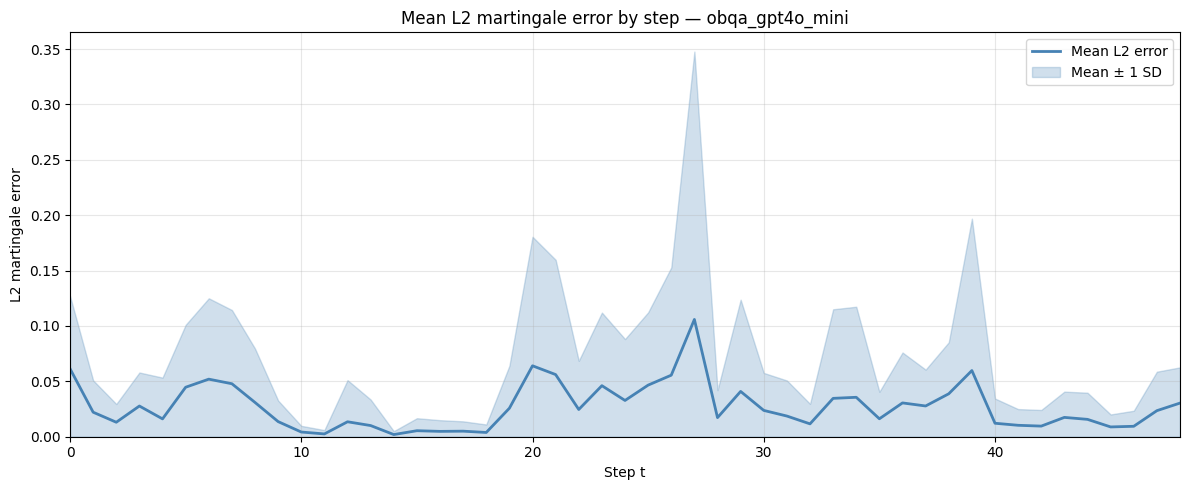

In [13]:
plot_l2_errors(dat["error_l2"], class_labels=labels, dataset_key=DATASET_KEY)

In [14]:
def plot_current_vs_expected_p(probs, expected_probs, dataset_key=DATASET_KEY):
    ## Expected next probabilities versus current probabilities
    p = probs
    e = expected_probs

    # expected_next has T-1 steps, so compare it with p_t at the same
    # non-final steps. Flattening includes every question, trajectory, step,
    # and class as one point in the scatter plot.
    x = p[..., :-1, :].ravel()
    y = e.ravel()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x, y, s=14, alpha=0.25, color="steelblue", edgecolors="none")

    # Perfect local martingale consistency lies on this diagonal.
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="y = x")
    ax.set_xlabel(r"Current probability $p_t(c)$")
    ax.set_ylabel(r"Expected next probability $E[p_{t+1}(c) \mid \mathcal{F}_t]$")
    ax.set_title(f"Expected vs. current class probabilities — {dataset_key}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


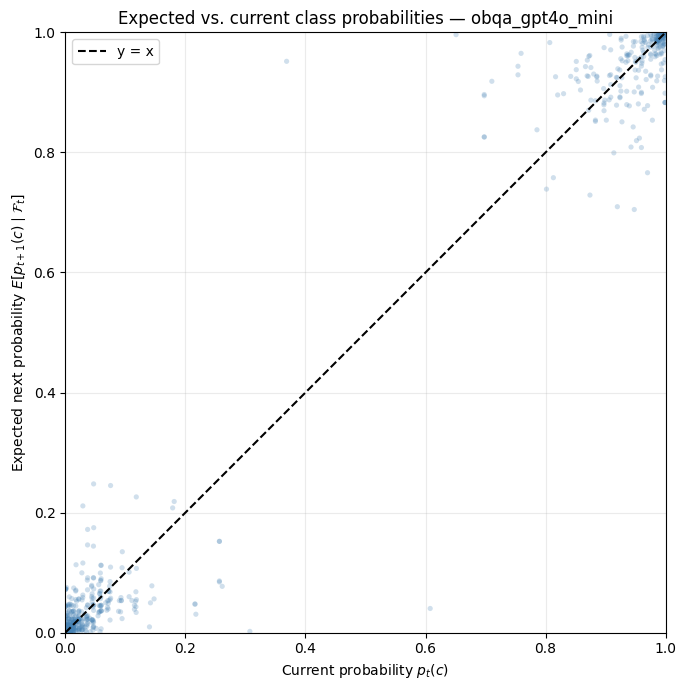

In [15]:
plot_current_vs_expected_p(dat["probs"], dat["expected_next"])

In [16]:
# def conditional_residual_bootstrap(
#     probabilities,
#     residuals,
#     bin_edges=(0.0, 0.2, 0.4, 0.6, 0.8, 1.000001),
#     n_bootstrap=20_000,
#     confidence=0.95,
#     seed=42,
# ):
#     """
#     Estimate E[residual | current probability bin].

#     probabilities: (Q, J, T+1, C)
#     residuals:     (Q, J, T, C)
#     """
#     probabilities = np.asarray(probabilities, dtype=np.float64)
#     residuals = np.asarray(residuals, dtype=np.float64)

#     # Each residual r_t corresponds to the current probability p_t.
#     current_probabilities = probabilities[..., :-1, :]

#     if current_probabilities.shape != residuals.shape:
#         raise ValueError(
#             f"Shape mismatch: current probabilities have shape "
#             f"{current_probabilities.shape}, residuals have shape "
#             f"{residuals.shape}"
#         )

#     Q, J, T, C = residuals.shape
#     n_trajectories = Q * J

#     # Keep all time steps and classes from a trajectory in one row.
#     current = current_probabilities.reshape(n_trajectories, T * C)
#     resid = residuals.reshape(n_trajectories, T * C)

#     bin_edges = np.asarray(bin_edges)
#     n_bins = len(bin_edges) - 1

#     # Contributions from every trajectory to each probability bin.
#     cluster_sums = np.zeros((n_trajectories, n_bins))
#     cluster_counts = np.zeros((n_trajectories, n_bins), dtype=int)

#     for g in range(n_trajectories):
#         for b in range(n_bins):
#             lower, upper = bin_edges[b], bin_edges[b + 1]

#             if b == n_bins - 1:
#                 mask = (current[g] >= lower) & (current[g] <= upper)
#             else:
#                 mask = (current[g] >= lower) & (current[g] < upper)

#             cluster_sums[g, b] = resid[g, mask].sum()
#             cluster_counts[g, b] = mask.sum()

#     total_sums = cluster_sums.sum(axis=0)
#     total_counts = cluster_counts.sum(axis=0)

#     observed_means = np.divide(
#         total_sums,
#         total_counts,
#         out=np.full(n_bins, np.nan),
#         where=total_counts > 0,
#     )

#     rng = np.random.default_rng(seed)
#     bootstrap_means = np.full((n_bootstrap, n_bins), np.nan)

#     for i in range(n_bootstrap):
#         # Resample complete trajectories with replacement.
#         indices = rng.integers(
#             0, n_trajectories, size=n_trajectories
#         )

#         sampled_sums = cluster_sums[indices].sum(axis=0)
#         sampled_counts = cluster_counts[indices].sum(axis=0)

#         bootstrap_means[i] = np.divide(
#             sampled_sums,
#             sampled_counts,
#             out=np.full(n_bins, np.nan),
#             where=sampled_counts > 0,
#         )

#     alpha = 1.0 - confidence
#     ci_low = np.nanquantile(
#         bootstrap_means, alpha / 2, axis=0
#     )
#     ci_high = np.nanquantile(
#         bootstrap_means, 1 - alpha / 2, axis=0
#     )

#     results = pd.DataFrame({
#         "probability_bin": [
#             f"[{bin_edges[b]:.1f}, {bin_edges[b + 1]:.1f})"
#             for b in range(n_bins)
#         ],
#         "n_observations": total_counts,
#         "mean_residual": observed_means,
#         "ci_low": ci_low,
#         "ci_high": ci_high,
#         "zero_in_ci": (ci_low <= 0) & (ci_high >= 0),
#         "direction": np.where(
#             ci_low > 0,
#             "positive",
#             np.where(ci_high < 0, "negative", "not significant"),
#         ),
#     })

#     return results, bootstrap_means

In [17]:
# conditional_results, conditional_bootstrap_samples = (
#     conditional_residual_bootstrap(
#         probabilities=dat["probs"],
#         residuals=dat["residuals"],
#         bin_edges=(0.0, 0.2, 0.4, 0.6, 0.8, 1.000001),
#         n_bootstrap=20_000,
#         confidence=0.95,
#         seed=42,
#     )
# )

# display(conditional_results)

In [18]:
# x = np.arange(len(conditional_results))
# means = conditional_results["mean_residual"].to_numpy()
# lower = means - conditional_results["ci_low"].to_numpy()
# upper = conditional_results["ci_high"].to_numpy() - means

# fig, ax = plt.subplots(figsize=(9, 5))

# ax.errorbar(
#     x,
#     means,
#     yerr=np.vstack([lower, upper]),
#     fmt="o",
#     capsize=4,
# )

# ax.axhline(0, color="black", linestyle="--", linewidth=1)
# ax.set_xticks(x)
# ax.set_xticklabels(conditional_results["probability_bin"])
# ax.set_xlabel("Current class probability")
# ax.set_ylabel("Mean martingale residual")
# ax.set_title("Residual conditional on current probability")
# plt.show()

In [19]:
# def compare_correct_incorrect_states(
#     probs: np.ndarray,
#     error_l2: np.ndarray,
#     true_labels: np.ndarray,
#     n_bootstrap: int = 20_000,
#     confidence: float = 0.95,
#     seed: int = 42,
#     dataset_key: str = DATASET_KEY,
# ):
#     """Compare L2 martingale error in correct and incorrect states.

#     A state at transition t is correct when argmax(p_t) equals the
#     question's true label. Confidence intervals resample complete
#     (question, replication) trajectories, preserving dependence over time.
#     """
#     p = np.asarray(probs, dtype=np.float64)
#     errors = np.asarray(error_l2, dtype=np.float64)
#     labels_true = np.asarray(true_labels).reshape(-1)

#     if p.ndim != 4 or errors.ndim != 3:
#         raise ValueError("Expected probs (Q, J, T+1, C) and error_l2 (Q, J, T).")

#     Q, J, Tp1, C = p.shape
#     if errors.shape != (Q, J, Tp1 - 1):
#         raise ValueError(
#             f"Shape mismatch: probs={p.shape}, error_l2={errors.shape}."
#         )
#     if labels_true.shape != (Q,):
#         raise ValueError(f"true_labels must have shape ({Q},), got {labels_true.shape}.")

#     # error_l2[q, j, t] belongs to the current state p[q, j, t].
#     current_probs = p[..., :-1, :]
#     current_predictions = current_probs.argmax(axis=-1)
#     correct = current_predictions == labels_true[:, None, None]

#     n_trajectories = Q * J
#     n_steps = errors.shape[-1]
#     errors_by_trajectory = errors.reshape(n_trajectories, n_steps)
#     correct_by_trajectory = correct.reshape(n_trajectories, n_steps)
#     masks = [correct_by_trajectory, ~correct_by_trajectory]
#     group_names = ["Correct", "Incorrect"]

#     # Store a sum and count per trajectory. Bootstrap samples therefore
#     # always retain every dependent time step belonging to a trajectory.
#     cluster_sums = np.zeros((n_trajectories, 2), dtype=np.float64)
#     cluster_counts = np.zeros((n_trajectories, 2), dtype=np.int64)
#     trajectory_rows = []

#     for g in range(n_trajectories):
#         row = {"question": g // J, "trajectory": g % J}
#         for h, (group_name, mask) in enumerate(zip(group_names, masks)):
#             values = errors_by_trajectory[g, mask[g]]
#             cluster_sums[g, h] = values.sum()
#             cluster_counts[g, h] = len(values)
#             row[group_name] = values.mean() if len(values) else np.nan
#         trajectory_rows.append(row)

#     total_counts = cluster_counts.sum(axis=0)
#     if np.any(total_counts == 0):
#         missing = [group_names[h] for h in np.flatnonzero(total_counts == 0)]
#         raise ValueError(f"Cannot compare groups with no observed states: {missing}")

#     observed_means = cluster_sums.sum(axis=0) / total_counts
#     observed_difference = observed_means[1] - observed_means[0]

#     rng = np.random.default_rng(seed)
#     bootstrap_means = np.full((n_bootstrap, 2), np.nan)
#     for b in range(n_bootstrap):
#         indices = rng.integers(0, n_trajectories, size=n_trajectories)
#         sampled_sums = cluster_sums[indices].sum(axis=0)
#         sampled_counts = cluster_counts[indices].sum(axis=0)
#         bootstrap_means[b] = np.divide(
#             sampled_sums, sampled_counts,
#             out=np.full(2, np.nan), where=sampled_counts > 0,
#         )

#     alpha = 1.0 - confidence
#     quantiles = [alpha / 2, 1 - alpha / 2]
#     n_group_trajectories = (cluster_counts > 0).sum(axis=0)
#     group_inference_available = n_group_trajectories >= 2
#     group_ci = np.full((2, 2), np.nan)
#     for h in range(2):
#         if group_inference_available[h]:
#             group_ci[:, h] = np.nanquantile(bootstrap_means[:, h], quantiles)

#     difference_inference_available = bool(group_inference_available.all())
#     if difference_inference_available:
#         bootstrap_difference = bootstrap_means[:, 1] - bootstrap_means[:, 0]
#         difference_ci = np.nanquantile(bootstrap_difference, quantiles)
#         zero_in_difference_ci = bool(difference_ci[0] <= 0 <= difference_ci[1])
#     else:
#         difference_ci = np.array([np.nan, np.nan])
#         zero_in_difference_ci = np.nan
#         warnings.warn(
#             "A group occurs in fewer than two trajectories. Its boxplot and mean "
#             "are descriptive only; a clustered CI for the contrast cannot be estimated."
#         )

#     group_summary = pd.DataFrame({
#         "state": group_names,
#         "n_states": total_counts,
#         "n_contributing_trajectories": n_group_trajectories,
#         "mean_error_l2": observed_means,
#         "ci_low": group_ci[0],
#         "ci_high": group_ci[1],
#         "inference_available": group_inference_available,
#     })
#     difference_summary = pd.DataFrame({
#         "contrast": ["Incorrect - Correct"],
#         "difference": [observed_difference],
#         "ci_low": [difference_ci[0]],
#         "ci_high": [difference_ci[1]],
#         "zero_in_ci": [zero_in_difference_ci],
#         "inference_available": [difference_inference_available],
#     })
#     trajectory_summary = pd.DataFrame(trajectory_rows)

#     display(group_summary)
#     display(difference_summary)

#     # Boxplots use trajectory-level conditional means, rather than treating
#     # every dependent state as an independent point. Paired trajectories
#     # are connected to show within-trajectory changes.
#     fig, ax = plt.subplots(figsize=(8, 5))
#     plot_values = [trajectory_summary[name].dropna().to_numpy() for name in group_names]
#     ax.boxplot(plot_values, tick_labels=group_names, showmeans=True, widths=0.5)

#     jitter_rng = np.random.default_rng(seed)
#     for x_position, values in enumerate(plot_values, start=1):
#         jitter = jitter_rng.normal(0, 0.035, size=len(values))
#         ax.scatter(
#             x_position + jitter, values, alpha=0.75, s=35,
#             color=f"C{x_position - 1}", zorder=3,
#         )

#     paired = trajectory_summary.dropna(subset=group_names)
#     for _, row in paired.iterrows():
#         ax.plot([1, 2], [row["Correct"], row["Incorrect"]],
#                 color="0.75", alpha=0.55, linewidth=0.8, zorder=1)

#     ax.set_ylabel(r"Trajectory mean $\|r_t\|_2$")
#     ax.set_title(f"Martingale error in correct vs incorrect states — {dataset_key}")
#     ax.grid(axis="y", alpha=0.25)
#     plt.tight_layout()
#     plt.show()

#     return group_summary, difference_summary, trajectory_summary

In [20]:
# ## Shows almost nothing for now. Maybe halps when the number of questions & experiments is increased. 
# correctness_group_results, correctness_difference, trajectory_state_errors = (
#     compare_correct_incorrect_states(
#         probs=dat["probs"],
#         error_l2=dat["error_l2"],
#         true_labels=dat["true_labels"],
#         n_bootstrap=20_000,
#         confidence=0.95,
#         seed=42,
#         dataset_key=DATASET_KEY,
#     )
# )

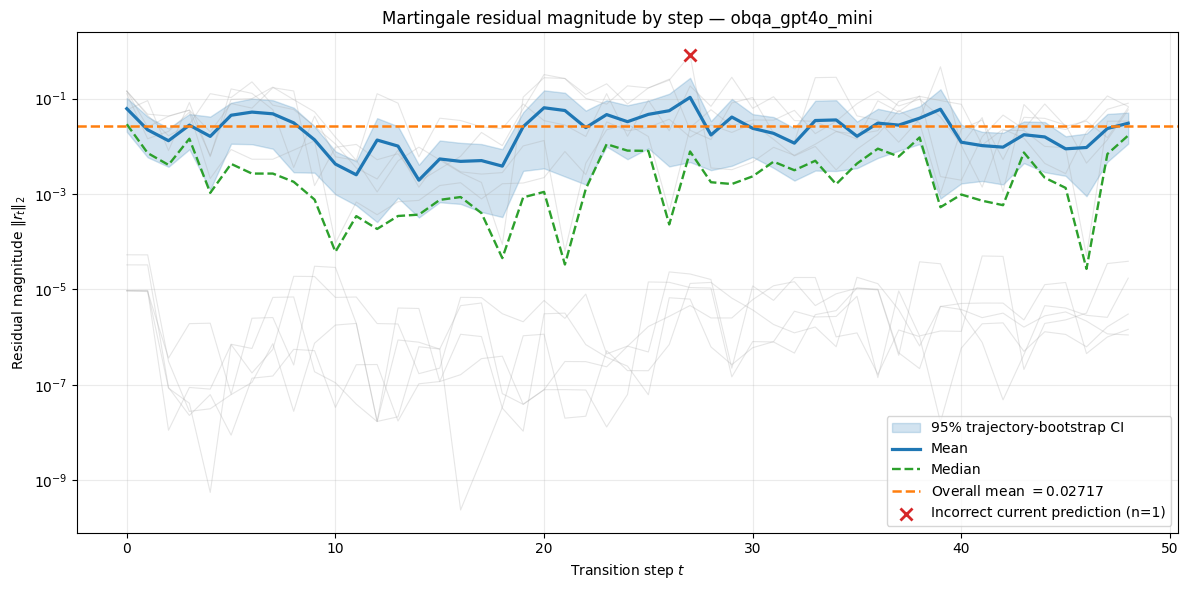

,step,mean_error_l2,median_error_l2,ci_low,ci_high
0,0,0.061397,0.028969,0.020117,0.102682
1,1,0.022134,0.007211,0.005868,0.041668
2,2,0.013080,0.004069,0.003715,0.023826
3,3,0.027722,0.014372,0.008623,0.047243
4,4,0.016103,0.001056,0.001239,0.041831


In [21]:
def plot_residual_l2_by_step(
    error_l2: np.ndarray,
    probs: np.ndarray = None,
    true_labels: np.ndarray = None,
    n_bootstrap: int = 10_000,
    confidence: float = 0.95,
    seed: int = 42,
    log_scale: bool = True,
    dataset_key: str = DATASET_KEY,
) -> pd.DataFrame:
    """Plot ||r_t||_2 against transition step t.

    Thin lines are complete trajectories. The thick line is the mean over
    trajectories and the shaded region is a pointwise trajectory-clustered
    bootstrap confidence interval for that mean.
    """
    errors = np.asarray(error_l2, dtype=np.float64)
    if errors.ndim != 3:
        raise ValueError("error_l2 must have shape (Q, J, T).")

    Q, J, T = errors.shape
    trajectories = errors.reshape(Q * J, T)
    n_trajectories = trajectories.shape[0]
    steps = np.arange(T)
    mean_by_step = np.nanmean(trajectories, axis=0)
    median_by_step = np.nanmedian(trajectories, axis=0)
    overall_mean = np.nanmean(trajectories)

    # Resample whole trajectories; never resample individual time steps.
    rng = np.random.default_rng(seed)
    bootstrap_means = np.empty((n_bootstrap, T), dtype=np.float64)
    for b in range(n_bootstrap):
        indices = rng.integers(0, n_trajectories, size=n_trajectories)
        bootstrap_means[b] = np.nanmean(trajectories[indices], axis=0)

    alpha = 1.0 - confidence
    ci_low, ci_high = np.nanquantile(
        bootstrap_means, [alpha / 2, 1 - alpha / 2], axis=0
    )

    step_summary = pd.DataFrame({
        "step": steps,
        "mean_error_l2": mean_by_step,
        "median_error_l2": median_by_step,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })

    fig, ax = plt.subplots(figsize=(12, 6))

    # Individual trajectory profiles show heterogeneity and spikes.
    for trajectory in trajectories:
        ax.plot(steps, trajectory, color="0.65", alpha=0.28, linewidth=0.8)

    ax.fill_between(
        steps, ci_low, ci_high, color="C0", alpha=0.20,
        label=f"{confidence:.0%} trajectory-bootstrap CI",
    )
    ax.plot(steps, mean_by_step, color="C0", linewidth=2.3, label="Mean")
    ax.plot(steps, median_by_step, color="C2", linewidth=1.7,
            linestyle="--", label="Median")
    ax.axhline(
        overall_mean, color="C1", linewidth=1.8, linestyle="--",
        label=fr"Overall mean $={overall_mean:.4g}$",
    )

    # Mark error values at states whose current argmax prediction is wrong.
    if probs is not None and true_labels is not None:
        p = np.asarray(probs, dtype=np.float64)
        labels_true = np.asarray(true_labels).reshape(-1)
        if p.shape[:3] != (Q, J, T + 1) or labels_true.shape != (Q,):
            raise ValueError(
                "probs must have shape (Q, J, T+1, C) and true_labels shape (Q,)."
            )
        predictions = p[..., :-1, :].argmax(axis=-1)
        incorrect = (predictions != labels_true[:, None, None]).reshape(Q * J, T)
        trajectory_indices, incorrect_steps = np.where(incorrect)
        if len(incorrect_steps):
            ax.scatter(
                incorrect_steps, trajectories[trajectory_indices, incorrect_steps],
                marker="x", s=75, linewidth=2, color="C3", zorder=5,
                label=f"Incorrect current prediction (n={len(incorrect_steps)})",
            )

    if log_scale:
        positive_values = trajectories[trajectories > 0]
        if positive_values.size:
            ax.set_yscale("log")

    ax.set_xlabel(r"Transition step $t$")
    ax.set_ylabel(r"Residual magnitude $\|r_t\|_2$")
    ax.set_title(f"Martingale residual magnitude by step — {dataset_key}")
    ax.grid(alpha=0.25, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return step_summary


residual_l2_by_step = plot_residual_l2_by_step(
    error_l2=dat["error_l2"],
    probs=dat["probs"],
    true_labels=dat["true_labels"],
    n_bootstrap=10_000,
    confidence=0.95,
    seed=42,
    log_scale=True,
    dataset_key=DATASET_KEY,
)

display(residual_l2_by_step.head())

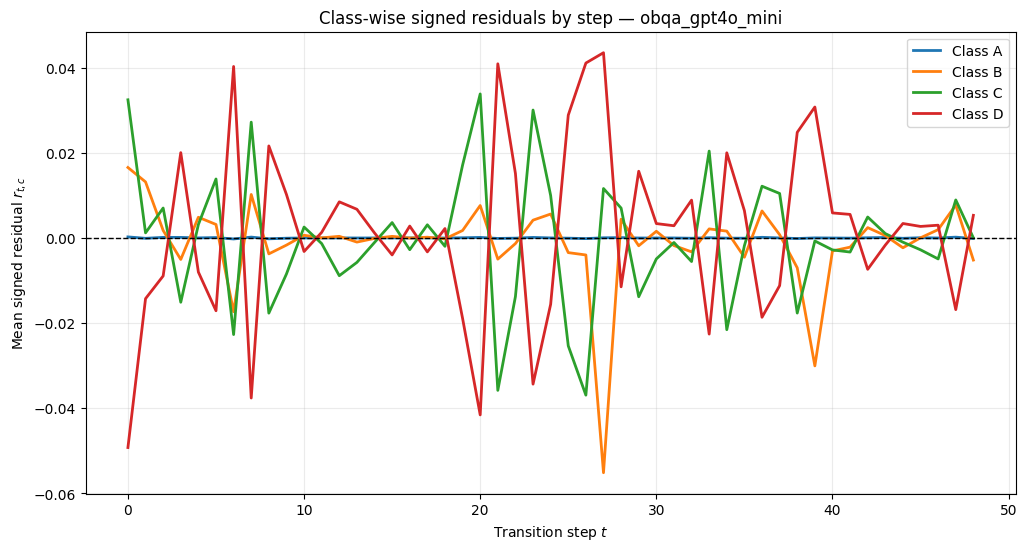

In [22]:
residuals = np.asarray(dat["residuals"])  # (Q, J, T, C)
mean_residuals = residuals.mean(axis=(0, 1))  # (T, C)

steps = np.arange(residuals.shape[2])
class_labels = dat["metadata"].get(
    "label_chars",
    range(residuals.shape[-1]),
)

fig, ax = plt.subplots(figsize=(12, 6))

for c, label in enumerate(class_labels):
    ax.plot(
        steps,
        mean_residuals[:, c],
        label=f"Class {label}",
        linewidth=2,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel(r"Transition step $t$")
ax.set_ylabel(r"Mean signed residual $r_{t,c}$")
ax.set_title(f"Class-wise signed residuals by step — {DATASET_KEY}")
ax.legend()
ax.grid(alpha=0.25)
plt.show()